# Convolutional Filters

## Introduction
Imagine that you find old family photographs in the attic. Unfortunately, the passage of time has caused the photos to become faded, noisy, and blurry. You want to restore them and bring back their former glory. You could spend many hours manually improving them in a graphics program, but what if it were possible to create one universal "magic filter" that automatically fixes every damaged photo?

In this task, your goal is precisely to create such a "recipe" for repairing images. This recipe, in the world of computer science and artificial intelligence, is called a **convolution kernel**. It is a fundamental tool in image processing and lies at the core of how computers "see" and understand the world.

## What Is Convolution?

Before we move on to the task, we need to understand two things: what an image is for a computer and how the "magic filter," i.e. convolution, works on it.

### What is an image for a computer?
For us, an image is a face, a landscape, or a cat. For a computer, it is simply a **large grid of numbers**. Each number in this grid corresponds to the brightness of a single **pixel**. In color images, we have three such grids — one for red (R), one for green (G), and one for blue (B).

### How does convolution work?
Convolution is an operation in which a small matrix of numbers (e.g. of size 3x3), called a **kernel**, is slid over the entire image, pixel by pixel.

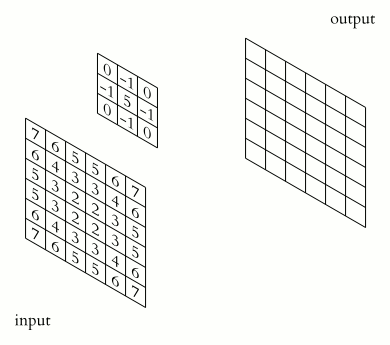


*Source: Michael Plotke, CC BY-SA 3.0 <https://creativecommons.org/licenses/by-sa/3.0>, via Wikimedia Commons*

For each position of the kernel on the image, we perform a simple operation:
1.  We take the fragment of the image under the kernel and **multiply** the corresponding pixel values and kernel weights.
2.  We **sum** all these results.
3.  The result of this sum becomes the **new pixel value** in the new, processed image.

Depending on what numbers we put into the kernel, we will obtain completely different effects.

## Examples of kernels

| Kernel (Macierz 3x3) | Efekt na obrazie |
|:---:|:---:|
| **Identyczność**<br>Jedynka w środku sprawia, że nowy piksel jest idealną kopią oryginalnego.<br> $$\begin{bmatrix} 0 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 0 \end{bmatrix}$$ | 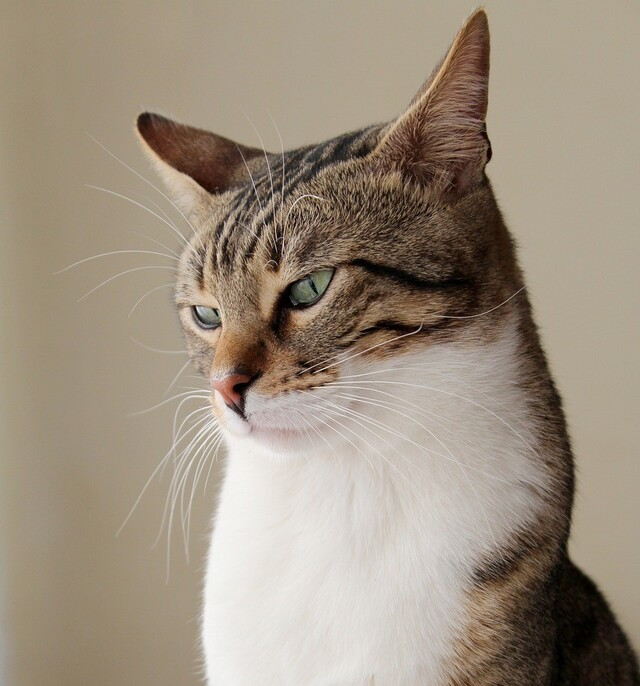 |
| **Rozmycie**<br>Uśrednia wartość piksela z jego sąsiadami, co wygładza obraz.<br> $$\begin{bmatrix} \frac{1}{9} & \frac{1}{9} & \frac{1}{9} \\ \frac{1}{9} & \frac{1}{9} & \frac{1}{9} \\ \frac{1}{9} & \frac{1}{9} & \frac{1}{9} \end{bmatrix}$$ | 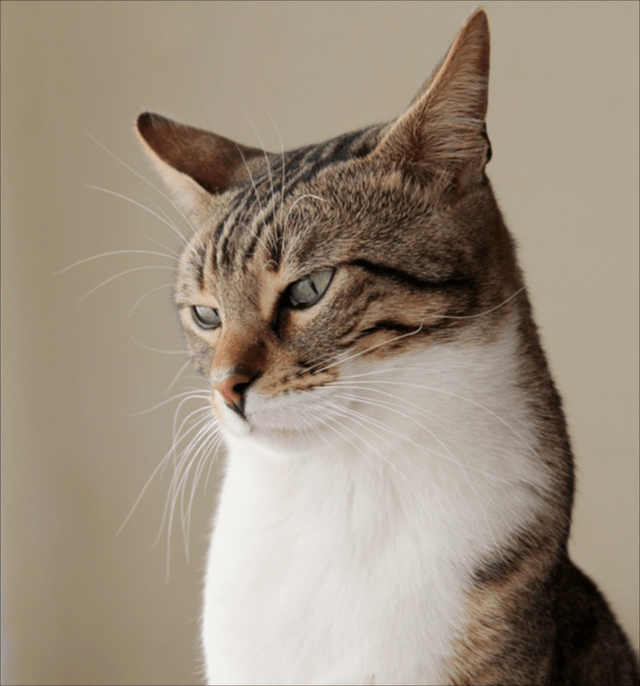 |
| **Wyostrzanie**<br>Podkreśla różnice między pikselem a jego otoczeniem, uwydatniając detale.<br> $$\begin{bmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0 \end{bmatrix}$$ | 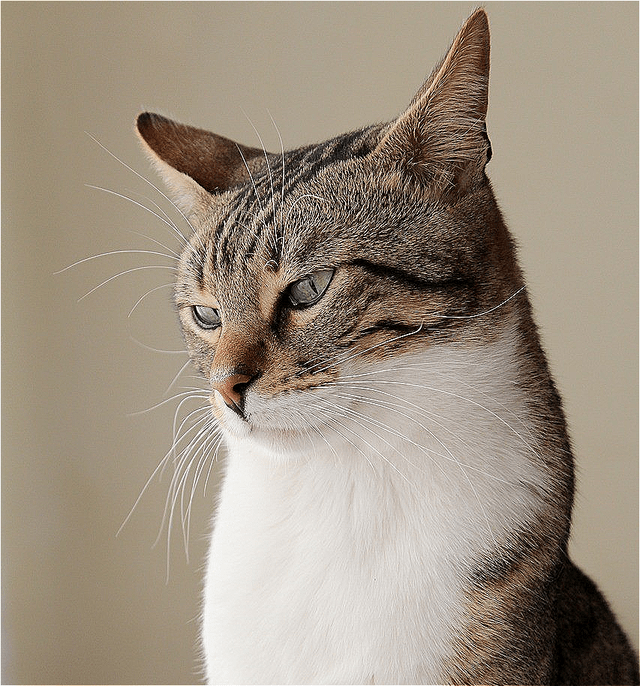 |
| **Wykrywanie krawędzi pionowych**<br>Wzmacnia miejsca, gdzie po lewej stronie są ciemne piksele, a po prawej jasne.<br> $$\begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}$$ | 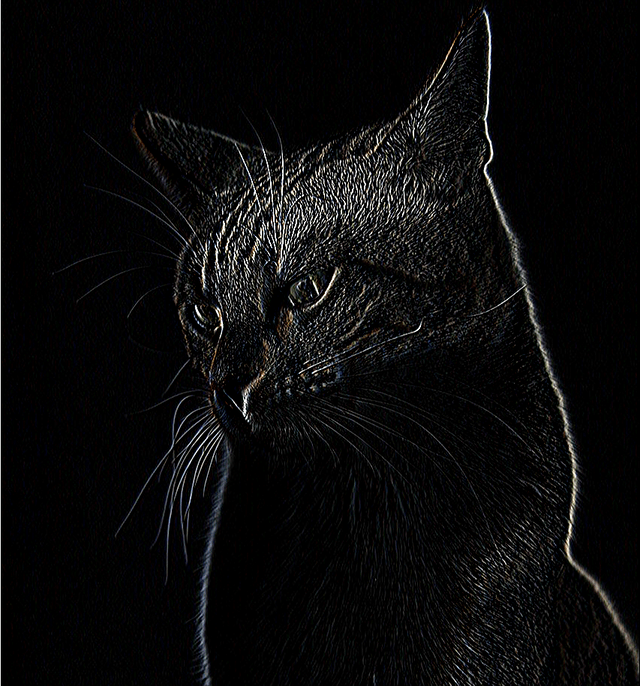 |


## And what is upsampling?

In the second part of the task, you will encounter the concept of **upsampling**, i.e. **enlarging an image**.
It is the opposite operation to downsampling:
we have a small image, e.g. 128x128 pixels, and we want to obtain a larger one — e.g. 256x256.

The problem is that the computer does not know what the values of the new, “invented” pixels should be.
Therefore, it has to somehow **guess** them.

The simplest way is to come up with a very simple rule, for example the following (called **nearest neighbor upsampling**):

> Each pixel from the small image is simply **replicated** horizontally and vertically as many times as needed to fill a larger block of pixels.

As a result, the enlarged image looks like an enlarged “mosaic” — shapes are preserved, but sharp edges and large pixels are clearly visible.

## Task

In this task, you will work on two related parts:

1.   Part one — Convolution kernel
2.   Part two — Upsampling (image enlargement)

Each of them is evaluated independently.

### Part 1 — Convolution kernel

Your task is to find **one universal kernel (filter)**,
which is able to restore corrupted photos to a form as close as possible to the originals.

*Note:* The kernel size should not exceed **10x10**.

As a starting point, you are given the function `compute_kernel()`,
which returns a simple filter — the so-called **blurring kernel** 9x9 (above you can find an example showing how such a kernel works in size 3x3).

Instead of manually selecting the weights, you can use the `autograd` mechanism from the PyTorch library. It is used for automatic optimization — in an iterative process, it will adjust the values in the kernel so that the image reconstruction error is as small as possible.

### Part 2 — Upsampling

In the second part, you will focus on the problem of image enlargement.

This time, your task is to implement the function `upsample(image: torch.Tensor) -> torch.Tensor`,
which receives a reduced image (`(C, h, w)`) and should enlarge it to full size (`(C, H, W)`).

The reference point (baseline) will be a very simple method,
**nearest neighbor**, which replicates each pixel the appropriate number of times vertically and horizontally.

In addition to the `upsample` function, you also have the option to choose an **additional kernel** (computed by the function `compute_kernel_upsampling(kernel_task1: torch.Tensor) -> torch.Tensor`), which will be applied *after* upsampling, already on the enlarged image. By default, this is the kernel from the first part of the task.

In this part, the quality of image reconstruction after two stages is evaluated:

1. **upsampling (the `upsample()` function)**,
2. **convolution with your kernel (the `compute_kernel_upsampling(...)` function)**.

## Data

In this task, two datasets saved in a single file (`train_val.npz`) are available to you:

*   `train_ds` — **150 training examples**,
*   `val_ds` — **50 validation examples**.

Each example is a **triple of related images**:


*   `image_original` – the original, correct image at a resolution of **256x256 pixels**,
*   `image_corrupted` – the same image after distortion, also **256x256**,
*   `image_corrupted_downsampled` – the `image_corrupted` version reduced to **128x128**,
on which you will test your upsampling methods.

All images are color (RGB) and stored as **PyTorch tensors** with shape `(3, H, W)`
and values normalized to the range **[0, 1]**.

## Evaluation Criterion
Both parts of the task will be evaluated based on the **MSE (Mean Squared Error)** metric. It is a simple way to measure how different two images are. This metric computes the difference between each pixel in the reconstructed image and the original one, squares these differences, and then takes their mean.

**The lower the MSE value, the more similar the images are, and the better your solution is.**

### Part 1 (70 pts.) - Convolution kernel
- For this part, you can score a maximum of 70 points.
- If the MSE value for your solution is 0.0285 (or higher), you will receive 0 points for this part of the task.
- If the MSE value for your solution is 0.0077 (or lower), you will receive 70 points for this part of the task.
- Otherwise, the number of points will be determined proportionally to the MSE value:
$$
\text{score} _ \text{kernel} = round(\frac{0.0285 - \text{MSE} _ \text{kernel}}{0.0285 - 0.0077} \times 70)
$$

### Part 2 (30 pts.) - Upsampling
- For this part, you can score a maximum of 30 points.
- If the MSE value for your solution is 0.0542 (or higher), you will receive 0 points for this part of the task.
- If the MSE value for your solution is 0.0350 (or lower), you will receive 30 points for this part of the task.
- Otherwise, the number of points will be determined proportionally to the MSE value:
$$
\text{score} _ \text{upsampling} = round(\frac{0.0542 - \text{MSE} _ \text{upsampling}}{0.0542 - 0.0350} \times 30)
$$

### Final score

The final score is the sum of the results from both parts:
$$
\text{Final score} = \text{score} _ \text{kernel} + \text{score} _ \text{upsampling}
$$
that is:
- **70% of the points** comes from the quality of your kernel (the `compute_kernel()` function)
- **30% of the points** from the quality of your `upsample()` and `compute_kernel_upsampling()` functions.

## Constraints
- Your solution will be tested on the Competition Platform without internet access and in an environment with a GPU.
- Evaluation of your final solution on the Competition Platform may not take longer than 3.5 minutes with GPU.
- Allowed libraries: `numpy`, `torch` (in the solution you **may not** use the `torch.nn` module).

## Submission Files
This notebook completed with your solution (the functions `compute_kernel`, `compute_kernel_upsampling`, and `upsample`).

## Evaluation
Remember that during checking, the `FINAL_EVALUATION_MODE` flag will be set to `True`.

For this task, you can score between 0 and 100 points. The number of points you obtain will be calculated on the (secret) test set on the Competition Platform based on the formula mentioned above, rounded to an integer. If your solution does not meet the above criteria or does not execute correctly, you will receive 0 points for the task.

## Starter Code
In this section, we initialize the environment by importing the necessary libraries and functions. The prepared code will help you efficiently work with the data and build the correct solution.

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

FINAL_EVALUATION_MODE = False  # Podczas sprawdzania ustawimy tę flagę na True.

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

if not FINAL_EVALUATION_MODE:
    import matplotlib.pyplot as plt

import os
import torch
import numpy as np
import math
import shutil
from typing import Callable, Optional

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

seed = 12345

os.environ["PYTHONHASHSEED"] = str(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
# Komórka zawierająca funkcje pomocnicze do przygotowania danych.


def download_data() -> None:
    """Pobiera zbiór danych z Google Drive i zapisuje go w folderze 'data'."""
    import gdown

    # Utwórz lub zresetuj folder 'data'
    if not os.path.exists("data"):
        os.makedirs("data")
    else:
        shutil.rmtree("data")
        os.makedirs("data")

    # Pobierz plik z Google Drive i zapisz go w folderze 'data'
    url = "https://drive.google.com/file/d/1wzYqBQ56IMXpM7_gv05vzercvZSZy-Ps/view?usp=drive_link"
    output = f"data/train_val.npz"
    gdown.download(url, output, quiet=True, fuzzy=True)


def setup_data_from_npz(npz_path: str) -> tuple[list[dict], list[dict]]:
    """
    Ładuje trójki obrazów (oryginalne, zepsute i zmniejszone (downsampled)
    zepsute) z pliku NPZ i zwraca je w postaci dwóch list słowników.

    Przyjmuje:
        npz_path (str): Ścieżka do pliku .npz z danymi.

    Zwraca:
        tuple[list[dict], list[dict]]:
            - train_ds: lista słowników {'image_original': tensor,
                'image_corrupted': tensor, 'image_corrupted_downsampled': tensor}
            - val_ds:   lista słowników w tym samym formacie, ale dla walidacji.
    """
    # Ładowanie danych z pliku
    data = np.load(npz_path, allow_pickle=True)
    train_list = data["train_ds"].tolist()
    val_list = data["val_ds"].tolist()

    def to_tensor_triplet(sample: dict) -> dict:
        # Konwertujemy wczytane dane (uint8) na float32
        # i skalujemy je z powrotem do zakresu [0, 1] dzieląc przez 255.0
        return {
            "image_original": torch.from_numpy(sample["image_original"]).to(
                torch.float32
            )
            / 255.0,
            "image_corrupted": torch.from_numpy(sample["image_corrupted"]).to(
                torch.float32
            )
            / 255.0,
            "image_corrupted_downsampled": torch.from_numpy(
                sample["image_corrupted_downsampled"]
            ).to(torch.float32)
            / 255.0,
        }

    train_ds = [to_tensor_triplet(s) for s in train_list]
    val_ds = [to_tensor_triplet(s) for s in val_list]

    return train_ds, val_ds

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
# Komórka zawierająca funkcje pomocnicze do ewaluacji rozwiązania.


def _pad_replicate(x: torch.Tensor, pad: int) -> torch.Tensor:
    """
    „Dopełnienie przez powielanie” — dodaje ramkę z pikseli brzegowych obrazu.
    Przydaje się do operacji konwolucji (kernel w środku, brzeg nie „ucieka”).

    Przyjmuje:
        x (torch.Tensor): Obraz o kształcie (C, H, W).
        pad (int): Liczba pikseli do dodania po każdej stronie.

    Zwraca:
        torch.Tensor: Obraz o powiększonym rozmiarze (C, H+2*pad, W+2*pad).
    """
    if pad == 0:
        return x
    # Dopełnienie w pionie: duplikujemy pierwszy i ostatni wiersz.
    top = x[:, :1, :].expand(-1, pad, -1)
    bottom = x[:, -1:, :].expand(-1, pad, -1)
    xvb = torch.cat([top, x, bottom], dim=1)  # (C, H+2p, W)
    # Dopełnienie w poziomie: duplikujemy pierwszą i ostatnią kolumnę.
    left = xvb[:, :, :1].expand(-1, -1, pad)
    right = xvb[:, :, -1:].expand(-1, -1, pad)
    xpad = torch.cat([left, xvb, right], dim=2)  # (C, H+2p, W+2p)
    return xpad


def apply_kernel(image: torch.Tensor, kernel: torch.Tensor) -> torch.Tensor:
    """
    Zastosowanie tego samego filtra (kernela) do każdej składowej kanałowej obrazu.

    Przyjmuje:
        image (torch.Tensor): Obraz o kształcie (C, H, W) w zakresie [0,1].
        kernel (torch.Tensor): Filtr 2D o kształcie (K, K).

    Zwraca:
        torch.Tensor: Nowy obraz (C, H, W) po zastosowaniu kernela.
    """
    assert image.dim() == 3, "image musi mieć wymiary (C,H,W)"
    assert kernel.dim() == 2 and kernel.size(0) == kernel.size(
        1
    ), "kernel musi być kwadratem (K,K)"
    assert kernel.size(0) <= 10, "rozmiar kernela nie może przekraczać 10x10"
    C, H, W = image.shape
    K = kernel.size(0)
    pad = K // 2

    # Dopełnienie replikacją (bez modyfikacji w miejscu — ważne dla autograd).
    xpad = _pad_replicate(image, pad)  # (C, H+2p, W+2p)

    # Tworzymy „okienka” z sąsiednich pikseli dla każdego miejsca w obrazie: (C, H, W, K, K)
    sC, sH, sW = xpad.stride()
    windows = xpad.as_strided(size=(C, H, W, K, K), stride=(sC, sH, sW, sH, sW))

    # Obliczamy korelację: mnożenie element po elemencie i sumowanie po sąsiedztwie KxK
    out = (windows * kernel.view(1, 1, 1, K, K)).sum(dim=(-1, -2))  # (C,H,W)
    return out


def evaluate_solution(
    kernel: torch.Tensor, ds: list[dict], upsample_fun: Optional[Callable] = None
) -> float:
    """
    Oblicza średni błąd MSE (Mean Squared Error) na podanym zbiorze danych.

    Przyjmuje:
        kernel (torch.Tensor): Filtr 2D (np. 5x5), który ma zostać oceniony.
        ds (list[dict]): Lista próbek z kluczami 'image_original',
            'image_corrupted' i 'image_corrupted_downsampled'.
        upsample_fun (Optional[Callable]): (Opcjonalnie) Funkcja do upsamplingu
            (torch.Tensor -> torch.Tensor), która ma zostać oceniona.

    Zwraca:
        float: Średnia wartość błędu MSE dla całego zbioru.
    """
    total_mse = 0.0
    kernel = kernel.to(DEVICE)

    # Nie potrzebujemy gradientów podczas ewaluacji — przyspiesza i oszczędza pamięć.
    with torch.no_grad():
        for sample in ds:
            original = sample["image_original"].to(DEVICE)

            # Wybór właściwej wersji "corrupted":
            # - jeśli podano funkcję upsamplingu, powiększamy wersję zmniejszoną,
            # - w przeciwnym razie bierzemy wersję w pełnym rozmiarze.
            if upsample_fun is not None:
                corrupted = sample["image_corrupted_downsampled"].to(DEVICE)
                corrupted = upsample_fun(corrupted)  # oczekujemy (C, H, W)
            else:
                corrupted = sample["image_corrupted"].to(DEVICE)  # już (C, H, W)

            # Rekonstrukcja obrazu przez zastosowanie kernela do „zepsutego” obrazu.
            reconstructed = apply_kernel(corrupted, kernel)
            # MSE: średnia z kwadratów różnic piksel po pikselu.
            mse = torch.mean((reconstructed - original) ** 2)
            total_mse += mse.item()

    return total_mse / len(ds)


def round_half_up(number: float) -> int:
    """
    Zaokrąglanie do najbliższej liczby całkowitej (.5 zawsze w górę).
    """
    return int(math.floor(number + 0.5))


def compute_score(kernel_mse: float, upsampling_mse: float) -> tuple[int, int, int]:
    """
    Przelicza dwa wyniki MSE (dla kernela i dla upsamplingu) na jedną ocenę 0–100.
    Każdy MSE jest osobno mapowany do skali punktowej na podstawie progów,
    a następnie łączony wagami.

    Przyjmuje:
        kernel_mse (float): Średni błąd MSE dla części 1 (kernel).
        upsampling_mse (float): Średni błąd MSE dla części 2 (upsampling).

    Zwraca:
        tuple[int, int, int]: Krotka zawierająca końcowy wynik (0–100),
            wynik za część 1 (kernel) i wynik za część 2 (upsampling).
    """

    # Progi jakości: im mniejsze MSE, tym lepiej.
    # 100 pkt dostaje się przy MSE <= lower_bound,
    # 0 pkt przy MSE >= upper_bound,
    # w przeciwnym razie — między 100 a 0 (wynik skalowany liniowo).

    KERNEL_LOWER = 0.0077
    KERNEL_UPPER = 0.0285
    UPS_LOWER = 0.0350
    UPS_UPPER = 0.0542

    # Wagi części zadania.
    KERNEL_W = 0.7
    UPS_W = 0.3

    def linear_score(mse: float, lower: float, upper: float) -> float:
        """
        Mapuje MSE na przedział [0,100] wg progów.
        - mse <= lower  -> 100
        - mse >= upper  -> 0
        - w środku      -> liniowo między 100 a 0
        """
        if mse <= lower:
            return 100.0
        if mse >= upper:
            return 0.0
        # im bliżej lower, tym więcej punktów
        return 100.0 * (upper - mse) / (upper - lower)

    kernel_score = round_half_up(
        KERNEL_W * linear_score(kernel_mse, KERNEL_LOWER, KERNEL_UPPER)
    )
    upsampling_score = round_half_up(
        UPS_W * linear_score(upsampling_mse, UPS_LOWER, UPS_UPPER)
    )

    # Łączymy punktację i przycinamy do [0,100] na wszelki wypadek.
    final_score = kernel_score + upsampling_score
    final_score = max(0, min(100, final_score))

    return final_score, kernel_score, upsampling_score

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
# Komórka zawierająca funkcje pomocnicze do wizualizacji.


def plot_results(
    original: torch.Tensor,
    corrupted: torch.Tensor,
    reconstructed: torch.Tensor,
    title: str = "Wyniki rekonstrukcji",
    labels: tuple = ("Oryginał", "Zepsuty", "Zrekonstruowany"),
    center_smaller: bool = True,
    background: float = 1.0,
    show_shapes: bool = True,
    clip_for_display: bool = True,
) -> None:
    """
    Wyświetla trzy obrazy obok siebie. Jeśli któryś obraz ma mniejszy rozmiar
    niż największy z pozostałych i `center_smaller=True`, jest tylko
    **wyśrodkowany** na płótnie o rozmiarze największego obrazu (za pomocą
    wypełnienia kolorem tła), aby rozmiary paneli były spójne wizualnie.

    Przyjmuje:
        original (torch.Tensor): Obraz wzorcowy w formacie (C, H, W), wartości w [0, 1].
        corrupted (torch.Tensor): Obraz „zepsuty” w formacie (C, h, w); może być mniejszy.
        reconstructed (torch.Tensor): Obraz po rekonstrukcji w formacie (C, H, W).
        title (str): Tytuł całej figury.
        labels (tuple): Podpisy nad panelami (od lewej): ("Oryginał", "Zepsuty", "Zrekonstruowany").
        center_smaller (bool): Gdy True, mniejsze obrazy są wyśrodkowane paddingiem (bez skalowania).
        background (float): Kolor tła (paddingu) w [0, 1]; 1.0 = białe, 0.0 = czarne.
        show_shapes (bool): Gdy True, rozmiary (wysokość×szerokość) dopisywane są do tytułów paneli.
        clip_for_display (bool): Gdy True, klipuje tylko kopię danych do [0,1]
            na potrzeby imshow (eliminuje warningi i „przepalenia” na ekranie).

    Zwraca:
        None
    """
    import numpy as np

    def to_hwc_np(t: torch.Tensor) -> np.ndarray:
        """
        Konwertuje tensor (C, H, W) na tablicę NumPy (H, W, C) w [0, 1],
        bez modyfikowania wartości.
        """
        return t.detach().cpu().permute(1, 2, 0).numpy()

    def pad_center(img_hwc: np.ndarray, target_hw: tuple, bg: float) -> np.ndarray:
        """
        Wkleja obraz (H, W, C) na środek płótna o rozmiarze target_hw (H_t, W_t).

        Przyjmuje:
            img_hwc (np.ndarray): Obraz wejściowy (H, W, C) w [0, 1].
            target_hw (tuple[int,int]): Docelowy rozmiar płótna (H_t, W_t).
            bg (float): Kolor tła w [0, 1].

        Zwraca:
            np.ndarray: Obraz (H_t, W_t, C) z obrazem wejściowym wyśrodkowanym.
        """
        Ht, Wt = target_hw
        h, w, c = img_hwc.shape
        # Jeśli rozmiary już się zgadzają albo nie chcemy centrować, zwracamy bez zmian
        if (h, w) == (Ht, Wt) or not center_smaller:
            return img_hwc

        # Tworzymy płótno tła i wklejamy obraz pośrodku
        canvas = np.full((Ht, Wt, c), bg, dtype=img_hwc.dtype)
        top = (Ht - h) // 2
        left = (Wt - w) // 2
        canvas[top : top + h, left : left + w, :] = img_hwc
        return canvas

    # Konwersja do HWC numpy
    img_o = to_hwc_np(original)
    img_c = to_hwc_np(corrupted)
    img_r = to_hwc_np(reconstructed)

    # Wspólna ramka = maksymalny rozmiar spośród wejść
    Hs = [img_o.shape[0], img_c.shape[0], img_r.shape[0]]
    Ws = [img_o.shape[1], img_c.shape[1], img_r.shape[1]]
    target_hw = (max(Hs), max(Ws))

    # Padding tylko jeśli potrzeba
    img_o_pad = pad_center(img_o, target_hw, background)
    img_c_pad = pad_center(img_c, target_hw, background)
    img_r_pad = pad_center(img_r, target_hw, background)

    # Opcjonalnie dopisz rozmiary do tytułów
    titles = list(labels)
    if show_shapes:
        titles[0] = f"{titles[0]} ({img_o.shape[0]}×{img_o.shape[1]})"
        titles[1] = f"{titles[1]} ({img_c.shape[0]}×{img_c.shape[1]})"
        titles[2] = f"{titles[2]} ({img_r.shape[0]}×{img_r.shape[1]})"

    # Opcjonalny klip tylko do wyświetlania
    if clip_for_display:

        def clip01(a: np.ndarray) -> np.ndarray:
            return np.clip(a, 0.0, 1.0, out=a.copy())

        show_o = clip01(img_o_pad)
        show_c = clip01(img_c_pad)
        show_r = clip01(img_r_pad)
    else:
        show_o, show_c, show_r = img_o_pad, img_c_pad, img_r_pad

    # Rysowanie
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, img, lab in zip(axes, (show_o, show_c, show_r), titles):
        ax.imshow(img, origin="upper")
        ax.set_title(lab)
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## Data Loading
Using the code below, the data will be downloaded and properly prepared.

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

if not FINAL_EVALUATION_MODE:
    download_data()

    # Ścieżka do jednego pliku NPZ z danymi (treningowe + walidacyjne)
    NPZ_PATH = os.path.join("data", "train_val.npz")

    # Wczytaj zbiory z NPZ
    train_ds, val_ds = setup_data_from_npz(
        NPZ_PATH
    )  # Zmienne te będą dostępne również podczas finalnej ewaluacji

    if train_ds is not None and val_ds is not None:
        print(f"Ilość obrazów w zbiorze treningowym: {len(train_ds)}")
        print(f"Ilość obrazów w zbiorze walidacyjnym: {len(val_ds)}")

        # Podgląd przykładowych danych
        sample_for_show = val_ds[0]
        plot_results(
            sample_for_show["image_original"],
            sample_for_show["image_corrupted"],
            sample_for_show["image_corrupted_downsampled"],
            title="Przykładowe dane z pliku NPZ",
            labels=("Oryginał", "Zepsuty", "Zepsuty (downsampled)"),
        )

## Your Solution
Below we present simplified solutions that serve as an example. These solutions achieve very poor results, but they demonstrate the expected output format and can serve as a starting point for your implementation.

In this section, you should place your solution. Make changes **only here**. For evaluation, the following functions will be passed:
- `compute_kernel() -> torch.Tensor`,
- `upsample(image: torch.Tensor) -> torch.Tensor`,
- `compute_kernel_upsampling(kernel_task1: torch.Tensor) -> torch.Tensor`

You may call additional helper functions in their context.

The previously prepared training and validation data are available in the variables `train_ds`, `val_ds`.

### Part 1 - Convolution kernel

In [ ]:
def compute_kernel() -> torch.Tensor:
    """
    Creates a blurring kernel of size 9x9.
    """
    kernel = torch.ones(9, 9, device=DEVICE) / 81
    return kernel

### Part 2 - Upsampling

In [ ]:
def upsample(image: torch.Tensor) -> torch.Tensor:
    """
    Simple upsampling using the “nearest neighbor” method
    to size 256x256.

    Idea:
    Each pixel from the smaller image is simply replicated several times
    vertically and horizontally. Thanks to this, the image becomes larger,
    but no new details appear – we only see “stretched” original pixels.

    Takes:
        image (torch.Tensor): Image in the format (C, h, w), where:
            - C is the number of channels (e.g. 3 for RGB),
            - h, w are the height and width of the image (≤ 256).

    Returns:
        torch.Tensor: An image of shape (C, 256, 256) obtained by
        repeating the rows and columns of the input as many times as needed
        to cover the entire target size, and then cropping to the exact
        dimensions 256x256.
    """
    assert image.dim() == 3, "I expect a tensor of shape (C, h, w)."
    C, h, w = image.shape

    # Target dimensions.
    Ht, Wt = (256, 256)

    # How many times we need to repeat rows and columns to reach >= 256.
    rh = max(1, math.ceil(Ht / h))
    rw = max(1, math.ceil(Wt / w))

    # repeat_interleave replicates consecutive rows/columns
    # the appropriate number of times.
    y = image.repeat_interleave(rh, dim=1).repeat_interleave(rw, dim=2)

    # It may happen that there are “too many” repetitions – then we crop to 256x256.
    return y[:, :Ht, :Wt]

In [ ]:
def compute_kernel_upsampling(kernel_task1: torch.Tensor) -> torch.Tensor:
    """
    During evaluation, the kernel from the first part will be passed
    as an argument. You may use it or ignore it.
    """
    return kernel_task1

## Evaluation

Running the cell below will allow you to check how many points your solution would score on the validation data.

Before submitting, make sure that the entire notebook runs from start to finish without errors and without any user intervention after executing the `Run All` command.

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################

if not FINAL_EVALUATION_MODE:

    # ============== 1) First part of the task ==============
    # -- Training
    your_kernel = compute_kernel()
    # -- Solution evaluation
    your_kernel_mse = evaluate_solution(your_kernel, val_ds)

    # ============== 2) Second part of the task ==============
    # -- Training
    your_kernel_upsampling = compute_kernel_upsampling(your_kernel)
    # -- Solution evaluation
    your_upsampling_mse = evaluate_solution(your_kernel_upsampling, val_ds, upsample)

    score, kernel_score, upsampling_score = compute_score(
        your_kernel_mse, your_upsampling_mse
    )

    print(
        f"MSE on the validation set (kernel): {your_kernel_mse:.4f}. Number of points (kernel): {kernel_score}"
    )
    print(
        f"MSE on the validation set (upsampling): {your_upsampling_mse:.4f}. Number of points (upsampling): {upsampling_score}"
    )
    print(f"Estimated number of points for the task: {score}")

    # Visualization of the kernel's operation on a single validation image.
    sample_for_show = val_ds[0]
    reconstructed = apply_kernel(
        sample_for_show["image_corrupted"].to(DEVICE), your_kernel.to(DEVICE)
    )
    plot_results(
        sample_for_show["image_original"],
        sample_for_show["image_corrupted"],
        reconstructed,
        title="Visualization of your kernel's operation",
    )

    # Preview of the kernel itself (color map).
    plt.figure(figsize=(5, 5))
    plt.imshow(your_kernel.cpu().detach().numpy(), cmap="viridis")
    plt.colorbar()
    plt.title("Your kernel")
    plt.show()

    # Visualization of the upsampling operation with the kernel on a single validation image.
    reconstructed = apply_kernel(
        upsample(sample_for_show["image_corrupted_downsampled"].to(DEVICE)),
        your_kernel_upsampling,
    )
    plot_results(
        sample_for_show["image_original"],
        sample_for_show["image_corrupted_downsampled"],
        reconstructed,
        title="Visualization of your upsampling method with kernel",
        labels=("Original", "Corrupted (downsampled)", "Reconstructed"),
    )